# Library

In [21]:
!pip install catboost
!pip install optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import optuna

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

# Load Data & EDA

In [4]:
df = pd.read_csv('/content/data_training.csv')

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8        5  1366  
1      9.2        5   103  
2 

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


In [6]:
# Missing value
print(df.isnull().sum())

# Hapus duplikat
df = df.drop_duplicates()

# Drop kolom tidak relevan
df = df.drop(columns=['Id'])

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


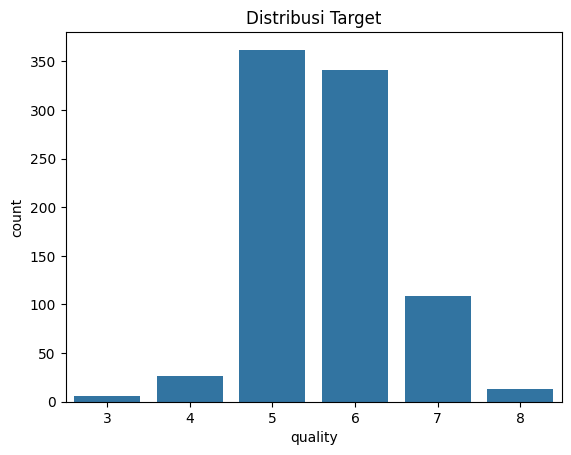

quality
5    0.422404
6    0.397900
7    0.127188
4    0.030338
8    0.015169
3    0.007001
Name: proportion, dtype: float64


In [7]:
plt.figure()
sns.countplot(x='quality', data=df)
plt.title("Distribusi Target")
plt.show()

print(df['quality'].value_counts(normalize=True))

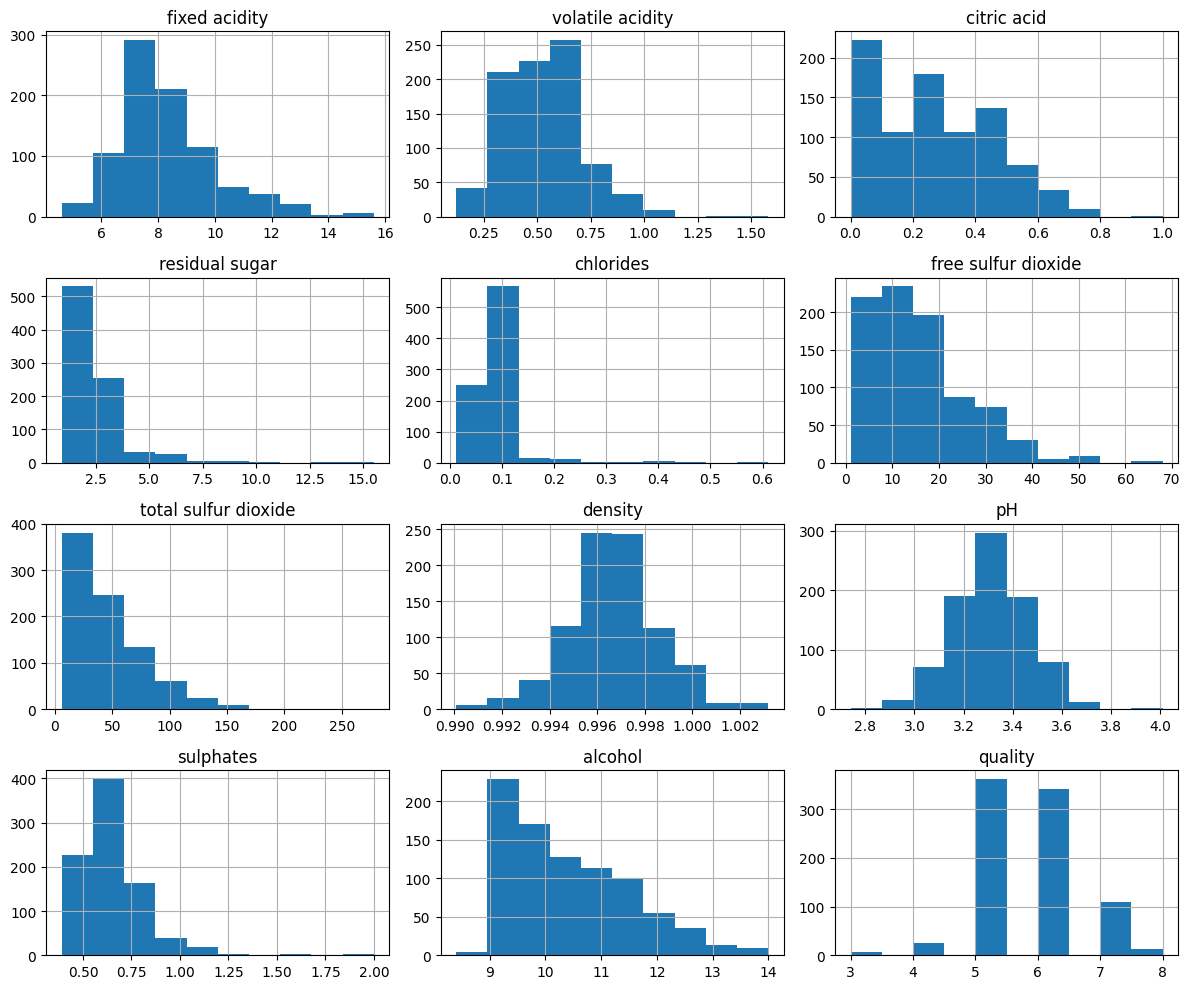

In [8]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

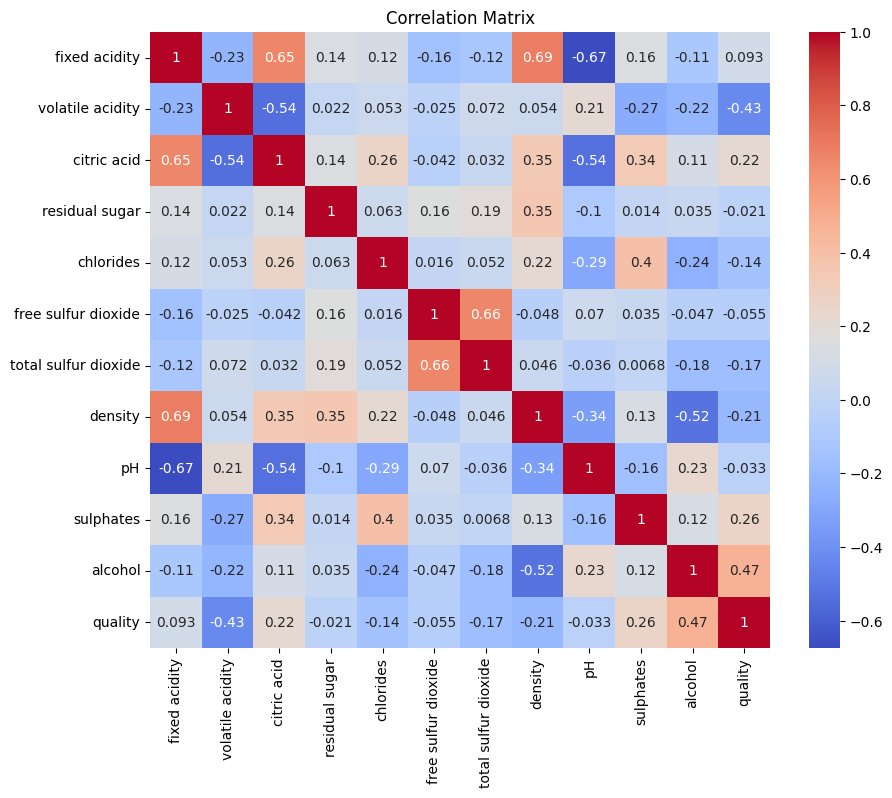

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df.drop('quality', axis=1)
y = df['quality']

In [13]:

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(3): np.float64(23.805555555555557), np.int64(4): np.float64(5.493589743589744), np.int64(5): np.float64(0.39456721915285453), np.int64(6): np.float64(0.41886608015640275), np.int64(7): np.float64(1.3103975535168195), np.int64(8): np.float64(10.987179487179487)}


In [17]:
def objective(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 128),
        'verbose': 0,
        'class_weights': class_weights
    }

    model = CatBoostClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0
        )

        preds = model.predict(X_val)
        score = f1_score(y_val, preds, average='macro')
        f1_scores.append(score)

    return np.mean(f1_scores)

In [23]:
study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=100)

[I 2026-05-03 07:35:19,973] A new study created in memory with name: no-name-2d9566c8-0255-46ed-a115-00fa486226c6
[I 2026-05-03 07:35:43,765] Trial 0 finished with value: 0.3267438996662926 and parameters: {'iterations': 704, 'depth': 9, 'learning_rate': 0.043210496962268155, 'l2_leaf_reg': 6, 'border_count': 121}. Best is trial 0 with value: 0.3267438996662926.
[I 2026-05-03 07:36:40,973] Trial 1 finished with value: 0.30993957530067096 and parameters: {'iterations': 642, 'depth': 10, 'learning_rate': 0.05966327267815367, 'l2_leaf_reg': 6, 'border_count': 109}. Best is trial 0 with value: 0.3267438996662926.
[I 2026-05-03 07:36:43,836] Trial 2 finished with value: 0.27522063017769355 and parameters: {'iterations': 527, 'depth': 4, 'learning_rate': 0.06703500374537978, 'l2_leaf_reg': 9, 'border_count': 105}. Best is trial 0 with value: 0.3267438996662926.
[I 2026-05-03 07:36:56,793] Trial 3 finished with value: 0.2979365817936125 and parameters: {'iterations': 600, 'depth': 8, 'learnin

In [24]:
print("Best Params:", study.best_params)
print("Best F1 Score:", study.best_value)

Best Params: {'iterations': 406, 'depth': 10, 'learning_rate': 0.024095223367056814, 'l2_leaf_reg': 1, 'border_count': 61}
Best F1 Score: 0.36812969198285134


In [31]:
best_model = CatBoostClassifier(
    **study.best_params,
    verbose=100
)

best_model.fit(X, y, sample_weight=y.map(class_weights))

0:	learn: 1.7557767	total: 37.2ms	remaining: 15.1s
100:	learn: 0.5717940	total: 3.69s	remaining: 11.1s
200:	learn: 0.3220137	total: 8.42s	remaining: 8.59s
300:	learn: 0.2166108	total: 12.4s	remaining: 4.33s
400:	learn: 0.1581313	total: 16.1s	remaining: 201ms
405:	learn: 0.1559640	total: 16.3s	remaining: 0us


CatBoostClassifier(border_count=61, depth=10, iterations=406, l2_leaf_reg=1, learning_rate=0.024095223367056814, verbose=100)

In [33]:
y_pred = best_model.predict(X)

In [35]:
print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))

Accuracy: 0.9813302217036173

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       0.98      0.98      0.98       362
           6       0.99      0.98      0.98       341
           7       0.96      1.00      0.98       109
           8       1.00      1.00      1.00        13

    accuracy                           0.98       857
   macro avg       0.99      0.99      0.99       857
weighted avg       0.98      0.98      0.98       857



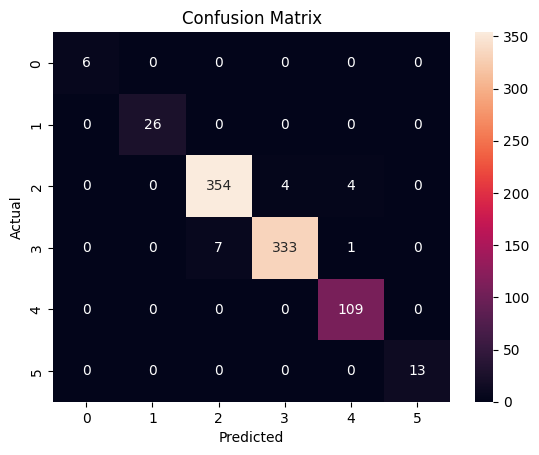

In [36]:
cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_scores = []

# Get best parameters from the study
best_params = study.best_params

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Calculate sample weights for the current training fold
    fold_sample_weights = y_train.map(class_weights)

    # Re-instantiate the model for each fold to ensure a fresh start
    model_for_fold = CatBoostClassifier(
        **best_params,
        verbose=0 # Suppress verbose output during CV folds
    )

    model_for_fold.fit(X_train, y_train, sample_weight=fold_sample_weights)
    preds = model_for_fold.predict(X_val)
    score = f1_score(y_val, preds, average='macro')
    cv_f1_scores.append(score)

print("CV Score:", cv_f1_scores)
print("Mean CV:", np.mean(cv_f1_scores))

CV Score: [0.3725997295469912, 0.28130438221800347, 0.3482368274778142, 0.39608065448401586, 0.3138957694009305]
Mean CV: 0.34242347262555106


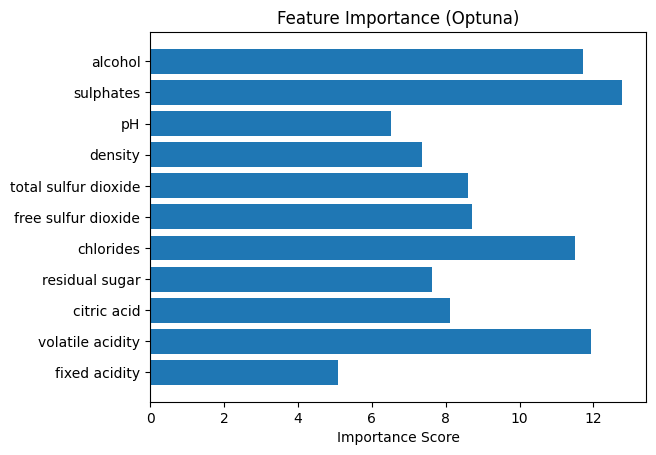

In [39]:
importances = best_model.get_feature_importance()

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance (Optuna)")
plt.xlabel("Importance Score")
plt.show()

In [40]:
best_model.save_model("catboost_optuna.cbm")

with open("feature_list.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [41]:
model = CatBoostClassifier()
model.load_model("catboost_optuna.cbm")

CatBoostClassifier(border_count=61, depth=10, iterations=406, l2_leaf_reg=1, learning_rate=0.02409522337, loss_function='MultiClass', verbose=100)

In [42]:
with open("feature_list.pkl", "rb") as f:
    feature_cols = pickle.load(f)

In [43]:
data_baru = pd.read_csv('/content/data_testing.csv')

data_baru = data_baru.drop(columns=['Id'])
data_baru = data_baru[feature_cols]

In [44]:
prediksi = model.predict(data_baru)

data_baru['prediksi_quality'] = prediksi

print(data_baru.head())

# Simpan hasil
data_baru.to_csv("hasil_prediksi.csv", index=False)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            6.8              0.61         0.04             1.5      0.057   
1            6.9              0.84         0.21             4.1      0.074   
2            7.0              0.58         0.12             1.9      0.091   
3            7.8              0.48         0.68             1.7      0.415   
4           12.5              0.60         0.49             4.3      0.100   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                  5.0                  10.0  0.99525  3.42       0.60   
1                 16.0                  65.0  0.99842  3.53       0.72   
2                 34.0                 124.0  0.99560  3.44       0.48   
3                 14.0                  32.0  0.99656  3.09       1.06   
4                  5.0                  14.0  1.00100  3.25       0.74   

     alcohol  prediksi_quality  
0   9.500000                 5  
1   9.233333        

In [45]:
test_data_original = pd.read_csv('/content/data_testing.csv')

# Create a DataFrame with 'Id' and predicted 'quality'
hasil_submission = pd.DataFrame({
    'Id': test_data_original['Id'],
    'quality': prediksi.flatten() # Flatten the predictions if they are in a column vector
})

# Save the new DataFrame to a CSV file
hasil_submission.to_csv('id_dan_prediksi_quality.csv', index=False)

print("CSV 'id_dan_prediksi_quality.csv' created successfully with 'Id' and predicted 'quality'.")
print(hasil_submission.head())

CSV 'id_dan_prediksi_quality.csv' created successfully with 'Id' and predicted 'quality'.
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        7
